# Single-agent batch-information probe: opinion center and uncertainty width

这个 notebook 是广义信息—意见动力学框架中的一个**单 agent、单轮、确定性机制探针**。它不验证真实用户行为，只检查候选更新函数是否实现我们共同提出的行为直觉、边界条件与同步时序。

## 1. Question, decision, and framework link

- **Working mode:** Co-design + bounded mechanism Probe。
- **Probe type:** mechanism probe，不是文献复现。
- **Framework link:** pre-framework information–opinion ontology draft 0.2（provisional）。
- **Primary question:** 给定当前意见分布中心 $x_t$、宽度 $u_t$ 与一轮二元 messages，候选同步更新能否产生预期的中心移动与宽度变化？
- **Decision supported:** 是否将该函数族保留为后续比较的 provisional benchmark；运行成功不等于接受或验证机制。
- **Claim level:** 最多是 V0 规则验证和 V1 隔离子模型行为，不能支持网络、长期或群体层结论。

## 2. Decision state, provenance, and boundary contract

### Decision state

- **confirmed / user-selected:** 路线 A；内部状态为连续意见中心 $x\in[-1,1]$ 与不确定性宽度 $u\in[0,1]$。
- **confirmed / jointly developed:** 同步时序；$x_{t+1}$ 与 $u_{t+1}$ 都只读取旧快照 $(x_t,u_t)$ 和本轮批次。
- **provisional / jointly retained for testing:** 用净方向、批次一致性和饱和信息量驱动更新的具体函数族。
- **open:** 混合信息是抵消还是额外扩大不确定性；$x=0$ 时一致信息是否立即改变 $u$；参数大小及经验来源。
- **rejected for this probe:** 旧版独立 $S,C$、同轮 challenge→reconfirmation 链式更新和跨零重新赋予 $C$ 指称对象。

### Boundary contract

- 输入是用户控制的 $x_t,u_t,n_+,n_-$；messages 仅为等权支持 $(+1)$ 和反对 $(-1)$。
- 冻结信息生产、来源可信度、内容质量、网络、平台排序、记忆和行为表达。
- 单轮确定性更新；宽度不是随机“摇立场”，而是内部不确定性的状态摘要。
- agent 更新不反过来产生 messages。

## 3. Candidate mechanism family

令 $N=n_++n_-$。若 $N>0$：

$$b_t=\frac{n_+-n_-}{N},\qquad K_t=|b_t|,\qquad d_t=\operatorname{sign}(b_t),\qquad R_t=\frac{N}{N+\nu}.$$

$b_t$ 是净信息方向，$K_t$ 是批次内部一致性，$R_t$ 是边际递减的信息量。

### Center update

$$\lambda_t=\alpha R_tK_tu_t,$$

$$x_{t+1}=x_t+\lambda_t(d_t-x_t).$$

高 $u_t$ 使中心更易移动；完全平衡批次的 $K=0$。该式是凸组合，因此在 $0\leq\alpha\leq1$ 时保持 $x\in[-1,1]$。

### Width update

对 $x_t\neq0$ 定义 receiver–batch alignment：

$$A_t=\operatorname{sign}(x_t)b_t.$$

$$u_{t+1}=u_t+\beta R_t(1-u_t)[-A_t]_+-\beta R_tu_t[A_t]_+ +\gamma R_t(1-K_t)(1-u_t),$$

其中 $[z]_+=\max(z,0)$。反向一致信息扩大宽度，同向一致信息收窄宽度；$\gamma=0$ 是“混合信息抵消”的 baseline，$\gamma>0$ 是“混合信息扩大不确定性”的竞争机制。显示用 $C=1-u$ 只是派生量，不是独立状态。

## 4. Expected outcomes before running

1. 无 messages：$x,u$ 都不变。
2. 对 $x=-0.8,u=0.1$，全支持使中心右移并扩大宽度；全反对只小幅左移并小幅收窄。
3. 5 支持/5 反对在 $\gamma=0$ 时无净变化，在 $\gamma>0$ 时只扩大宽度。
4. 初始 $u$ 越大，同样输入造成的中心移动越大。
5. $u_t=0$ 时反向信息本轮不能移动中心，但可以先令 $u_{t+1}>0$。
6. 满足无输入不变性、正负镜像对称以及 $x\in[-1,1],u\in[0,1]$。
7. $x=0$ 的宽度规则仍是公开边界问题。

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)

## 5. Minimal specification and implementation

所有参数都是未校准的实验控制量。结果对象保留各机制分量，便于区分中心移动、反向动摇、同向确认和 mixed-conflict 的贡献。

In [2]:
@dataclass(frozen=True)
class EffectParams:
    alpha: float = 0.30
    beta: float = 0.20
    gamma_mixed: float = 0.00
    nu: float = 6.0

    def __post_init__(self) -> None:
        for name in ("alpha", "beta", "gamma_mixed"):
            if not 0.0 <= getattr(self, name) <= 1.0:
                raise ValueError(f"{name} must be in [0, 1].")
        if self.nu <= 0.0:
            raise ValueError("nu must be positive.")


@dataclass(frozen=True)
class UpdateResult:
    x_before: float
    u_before: float
    n_support: int
    n_oppose: int
    batch_valence: float
    coherence: float
    mixedness: float
    volume: float
    direction: float
    alignment: float
    center_gain: float
    delta_x: float
    widen_challenge: float
    narrow_confirmation: float
    widen_mixed: float
    x_after: float
    u_after: float

    @property
    def delta_u(self) -> float:
        return self.u_after - self.u_before

    @property
    def c_before(self) -> float:
        return 1.0 - self.u_before

    @property
    def c_after(self) -> float:
        return 1.0 - self.u_after


def _validate(x: float, u: float, n_support: int, n_oppose: int) -> None:
    if not -1.0 <= x <= 1.0:
        raise ValueError("x must be in [-1, 1].")
    if not 0.0 <= u <= 1.0:
        raise ValueError("u must be in [0, 1].")
    for name, value in (("n_support", n_support), ("n_oppose", n_oppose)):
        if isinstance(value, bool) or not isinstance(value, (int, np.integer)) or value < 0:
            raise ValueError(f"{name} must be a non-negative integer.")


def update_one_round(
    x: float,
    u: float,
    n_support: int,
    n_oppose: int,
    params: EffectParams = EffectParams(),
) -> UpdateResult:
    """Compute one synchronous deterministic update from the old state snapshot."""
    _validate(x, u, n_support, n_oppose)
    total = int(n_support + n_oppose)
    b = 0.0 if total == 0 else float((n_support - n_oppose) / total)
    volume = 0.0 if total == 0 else float(total / (total + params.nu))
    coherence = abs(b)
    mixedness = 0.0 if total == 0 else 1.0 - coherence
    direction = float(np.sign(b))
    alignment = float(np.sign(x) * b)

    center_gain = params.alpha * volume * coherence * u
    delta_x = center_gain * (direction - x)
    x_after = x + delta_x

    widen_challenge = params.beta * volume * (1.0 - u) * max(-alignment, 0.0)
    narrow_confirmation = params.beta * volume * u * max(alignment, 0.0)
    widen_mixed = params.gamma_mixed * volume * mixedness * (1.0 - u)
    u_after = u + widen_challenge - narrow_confirmation + widen_mixed

    if not (-1.0 - 1e-12 <= x_after <= 1.0 + 1e-12 and -1e-12 <= u_after <= 1.0 + 1e-12):
        raise AssertionError("Declared state domain was violated.")

    return UpdateResult(
        float(x), float(u), int(n_support), int(n_oppose), b, coherence, mixedness,
        volume, direction, alignment, center_gain, delta_x, widen_challenge,
        narrow_confirmation, widen_mixed, float(np.clip(x_after, -1.0, 1.0)),
        float(np.clip(u_after, 0.0, 1.0)),
    )


def compact_result(result: UpdateResult) -> pd.DataFrame:
    return pd.DataFrame({
        "state": ["x: opinion center", "u: uncertainty width", "C = 1-u (derived)"],
        "before": [result.x_before, result.u_before, result.c_before],
        "after": [result.x_after, result.u_after, result.c_after],
        "change": [result.delta_x, result.delta_u, result.c_after - result.c_before],
    }).round(4)

## 6. V0 deterministic, schedule, and boundary checks

这些断言只验证代码实现了候选规则，不验证规则符合真实行为。

In [3]:
def run_v0_checks() -> None:
    base = EffectParams(alpha=0.30, beta=0.20, gamma_mixed=0.0, nu=10.0)

    hand = update_one_round(-0.8, 0.1, 10, 0, base)  # R=0.5
    expected_gain = 0.30 * 0.50 * 1.0 * 0.1
    assert np.isclose(hand.x_after, -0.8 + expected_gain * 1.8)
    assert np.isclose(hand.u_after, 0.1 + 0.20 * 0.50 * 0.9)

    no_input = update_one_round(-0.3, 0.5, 0, 0, base)
    assert no_input.x_after == -0.3 and no_input.u_after == 0.5

    counter = update_one_round(-0.8, 0.1, 10, 0, base)
    aligned = update_one_round(-0.8, 0.1, 0, 10, base)
    balanced = update_one_round(-0.8, 0.1, 10, 10, base)
    assert counter.x_after > -0.8 and counter.u_after > 0.1
    assert aligned.x_after < -0.8 and aligned.u_after < 0.1
    assert np.isclose(balanced.x_after, -0.8) and np.isclose(balanced.u_after, 0.1)

    conflict = update_one_round(-0.8, 0.1, 10, 10, EffectParams(gamma_mixed=0.3))
    assert np.isclose(conflict.x_after, -0.8) and conflict.u_after > 0.1

    certain = update_one_round(-0.8, 0.0, 10, 0, base)
    assert np.isclose(certain.x_after, -0.8) and certain.u_after > 0.0

    low_u = update_one_round(-0.4, 0.1, 10, 0, base)
    high_u = update_one_round(-0.4, 0.8, 10, 0, base)
    assert abs(high_u.delta_x) > abs(low_u.delta_x)

    one = update_one_round(-0.4, 0.5, 1, 0, base)
    many = update_one_round(-0.4, 0.5, 20, 0, base)
    assert abs(many.delta_x) > abs(one.delta_x)

    for gamma in (0.0, 0.4, 1.0):
        params = EffectParams(alpha=0.7, beta=0.8, gamma_mixed=gamma, nu=2.0)
        for x in np.linspace(-1.0, 1.0, 17):
            for u in np.linspace(0.0, 1.0, 11):
                for ns in (0, 1, 3, 10):
                    for no in (0, 1, 3, 10):
                        result = update_one_round(float(x), float(u), ns, no, params)
                        mirror = update_one_round(float(-x), float(u), no, ns, params)
                        assert -1.0 <= result.x_after <= 1.0
                        assert 0.0 <= result.u_after <= 1.0
                        assert np.isclose(result.x_after, -mirror.x_after)
                        assert np.isclose(result.u_after, mirror.u_after)

    print("All V0 checks passed: exact case, schedule, qualitative cases, bounds, and symmetry.")


run_v0_checks()

All V0 checks passed: exact case, schedule, qualitative cases, bounds, and symmetry.


## 7. Editable one-case run

直接修改 $X_0,U_0$、正反 message 数和参数。默认值是“较确定的反对者收到完全一致的支持信息”。

In [4]:
X0 = -0.80
U0 = 0.10
N_SUPPORT = 10
N_OPPOSE = 0
PARAMS = EffectParams(alpha=0.30, beta=0.20, gamma_mixed=0.00, nu=6.0)

manual_result = update_one_round(X0, U0, N_SUPPORT, N_OPPOSE, PARAMS)
display(compact_result(manual_result))
pd.Series(
    {key: round(value, 4) if isinstance(value, float) else value for key, value in asdict(manual_result).items()},
    name="mechanism diagnostics",
)

,state,before,after,change
0,x: opinion center,-0.8,-0.7662,0.0338
1,u: uncertainty width,0.1,0.2125,0.1125
2,C = 1-u (derived),0.9,0.7875,-0.1125


x_before               -0.8000
u_before                0.1000
n_support              10.0000
n_oppose                0.0000
batch_valence           1.0000
coherence               1.0000
mixedness               0.0000
volume                  0.6250
direction               1.0000
alignment              -1.0000
center_gain             0.0188
delta_x                 0.0338
widen_challenge         0.1125
narrow_confirmation     0.0000
widen_mixed             0.0000
x_after                -0.7662
u_after                 0.2125
Name: mechanism diagnostics, dtype: float64

## 8. Interactive control panel

主控件改变 $x_t,u_t$ 和消息数量；高级参数未经过经验校准。图中同时显示单轮状态变化和固定当前状态时的 message-count landscape。

In [5]:
def render_probe(x, u, n_support, n_oppose, alpha, beta, gamma_mixed, nu):
    params = EffectParams(alpha, beta, gamma_mixed, nu)
    result = update_one_round(x, u, n_support, n_oppose, params)
    display(compact_result(result))
    display(pd.Series({
        "b: batch valence": result.batch_valence,
        "K: coherence": result.coherence,
        "A: alignment": result.alignment,
        "R(N): volume": result.volume,
        "challenge widening": result.widen_challenge,
        "confirmation narrowing": result.narrow_confirmation,
        "mixed widening": result.widen_mixed,
    }).round(4))

    limit = 30
    x_grid = np.empty((limit + 1, limit + 1))
    u_grid = np.empty_like(x_grid)
    for no in range(limit + 1):
        for ns in range(limit + 1):
            cell = update_one_round(x, u, ns, no, params)
            x_grid[no, ns], u_grid[no, ns] = cell.x_after, cell.u_after

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
    axes[0].hlines(0, -1, 1, color="0.4")
    axes[0].scatter([x, result.x_after], [0, 0], s=[90, 120], c=["0.4", "#d95f02"])
    axes[0].annotate("", xy=(result.x_after, 0), xytext=(x, 0), arrowprops={"arrowstyle": "->"})
    axes[0].set(xlim=(-1.05, 1.05), ylim=(-0.2, 0.2), yticks=[], title="center: before → after")
    extent = (-0.5, limit + 0.5, -0.5, limit + 0.5)
    im_x = axes[1].imshow(x_grid, origin="lower", extent=extent, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
    im_u = axes[2].imshow(u_grid, origin="lower", extent=extent, vmin=0, vmax=1, cmap="viridis", aspect="auto")
    for ax, title in zip(axes[1:], ("final center x'", "final width u'")):
        ax.scatter([n_support], [n_oppose], marker="s", s=80, facecolors="none", edgecolors="black", lw=2)
        ax.set(xlabel="support messages", ylabel="oppose messages", title=title)
    fig.colorbar(im_x, ax=axes[1], shrink=0.85)
    fig.colorbar(im_u, ax=axes[2], shrink=0.85)
    plt.show()


x_w = widgets.FloatSlider(value=-0.8, min=-1, max=1, step=0.05, description="Initial x", continuous_update=False)
u_w = widgets.FloatSlider(value=0.1, min=0, max=1, step=0.05, description="Initial u", continuous_update=False)
ns_w = widgets.IntSlider(value=10, min=0, max=30, description="Support +", continuous_update=False)
no_w = widgets.IntSlider(value=0, min=0, max=30, description="Oppose -", continuous_update=False)
alpha_w = widgets.FloatSlider(value=0.3, min=0, max=1, step=0.05, description="alpha", continuous_update=False)
beta_w = widgets.FloatSlider(value=0.2, min=0, max=1, step=0.05, description="beta", continuous_update=False)
gamma_w = widgets.FloatSlider(value=0.0, min=0, max=1, step=0.05, description="gamma mix", continuous_update=False)
nu_w = widgets.FloatSlider(value=6, min=0.5, max=30, step=0.5, description="nu", continuous_update=False)
controls = {"x": x_w, "u": u_w, "n_support": ns_w, "n_oppose": no_w, "alpha": alpha_w, "beta": beta_w, "gamma_mixed": gamma_w, "nu": nu_w}
output = widgets.interactive_output(render_probe, controls)
advanced = widgets.Accordion(children=[widgets.VBox([widgets.HBox([alpha_w, beta_w]), widgets.HBox([gamma_w, nu_w])])])
advanced.set_title(0, "Advanced provisional parameters")
display(widgets.VBox([widgets.HBox([x_w, u_w]), widgets.HBox([ns_w, no_w]), advanced]), output)

Output()

## 9. Micro-cases, consistency sweep, and exposed neutral boundary

先比较 $x=-0.8,u=0.1$ 的核心情形，再固定 $N=20$ 扫描支持比例。最后单列 $x=0$：当前规则允许一致信息移动中心，但 baseline 不立即改变宽度；这是未决边界，不是已确认假设。

b    K  x after  delta x  \
mechanism                 scenario                                            
baseline: mixed cancels   all support (counter)  1.0  1.0  -0.7662   0.0338   
                          support majority 6/4   0.2  0.2  -0.7932   0.0068   
                          balanced 5/5           0.0  0.0  -0.8000   0.0000   
                          oppose majority 4/6   -0.2  0.2  -0.8008  -0.0008   
                          all oppose (aligned)  -1.0  1.0  -0.8038  -0.0038   
alternative: mixed widens all support (counter)  1.0  1.0  -0.7662   0.0338   
                          support majority 6/4   0.2  0.2  -0.7932   0.0068   
                          balanced 5/5           0.0  0.0  -0.8000   0.0000   
                          oppose majority 4/6   -0.2  0.2  -0.8008  -0.0008   
                          all oppose (aligned)  -1.0  1.0  -0.8038  -0.0038   

                                                 u after  delta u  
mechanism                 scenario                                 
baseline: mixed cancels   all support (counter)   0.2125   0.1125  
                          support majority 6/4    0.1225   0.0225  
                          balanced 5/5            0.1000   0.0000  
                          oppose majority 4/6     0.0975  -0.0025  
                          all oppose (aligned)    0.0875  -0.0125  
alternative: mixed widens all support (counter)   0.2125   0.1125  
                          support majority 6/4    0.2575   0.1575  
                          balanced 5/5            0.2688   0.1688  
                          oppose majority 4/6     0.2325   0.1325  
                          all oppose (aligned)    0.0875  -0.0125

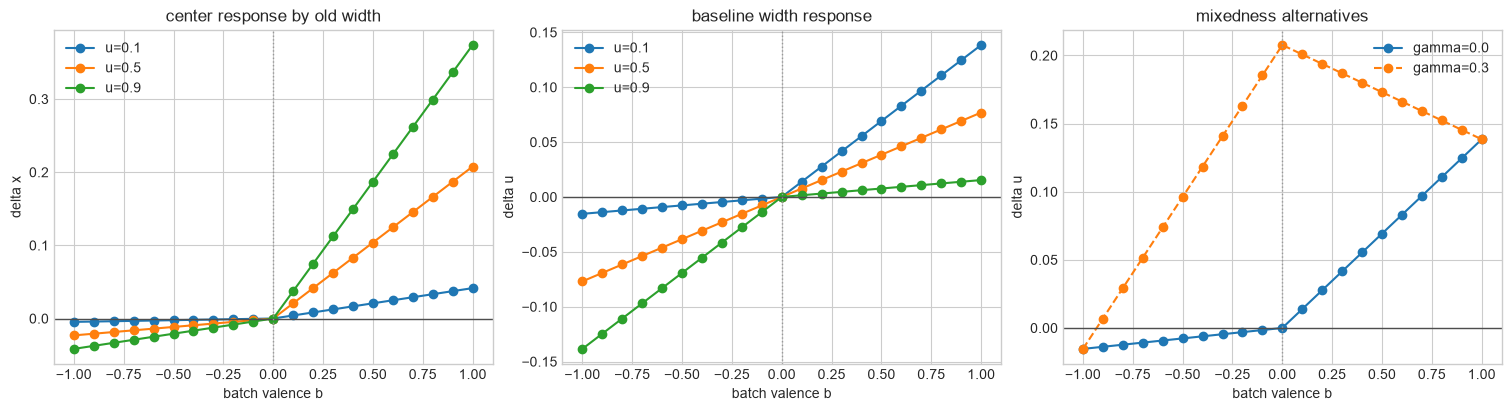

x after  u after  delta x  delta u
scenario    gamma                                    
all support 0.0     0.0938   0.5000   0.0938   0.0000
            0.3     0.0938   0.5000   0.0938   0.0000
balanced    0.0     0.0000   0.5000   0.0000   0.0000
            0.3     0.0000   0.5938   0.0000   0.0938
all oppose  0.0    -0.0938   0.5000  -0.0938   0.0000
            0.3    -0.0938   0.5000  -0.0938   0.0000

In [6]:
cases = {
    "all support (counter)": (10, 0),
    "support majority 6/4": (6, 4),
    "balanced 5/5": (5, 5),
    "oppose majority 4/6": (4, 6),
    "all oppose (aligned)": (0, 10),
}
rows = []
for mechanism, gamma in (("baseline: mixed cancels", 0.0), ("alternative: mixed widens", 0.3)):
    params = EffectParams(gamma_mixed=gamma)
    for scenario, (ns, no) in cases.items():
        r = update_one_round(-0.8, 0.1, ns, no, params)
        rows.append({"mechanism": mechanism, "scenario": scenario, "b": r.batch_valence, "K": r.coherence,
                     "x after": r.x_after, "delta x": r.delta_x, "u after": r.u_after, "delta u": r.delta_u})
display(pd.DataFrame(rows).set_index(["mechanism", "scenario"]).round(4))


def sweep(u, gamma=0.0, total=20):
    records = []
    for ns in range(total + 1):
        r = update_one_round(-0.8, u, ns, total - ns, EffectParams(gamma_mixed=gamma))
        records.append({"b": r.batch_valence, "delta_x": r.delta_x, "delta_u": r.delta_u})
    return pd.DataFrame(records)


fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for initial_u in (0.1, 0.5, 0.9):
    frame = sweep(initial_u)
    axes[0].plot(frame.b, frame.delta_x, marker="o", label=f"u={initial_u}")
    axes[1].plot(frame.b, frame.delta_u, marker="o", label=f"u={initial_u}")
for gamma, style in ((0.0, "-"), (0.3, "--")):
    frame = sweep(0.1, gamma)
    axes[2].plot(frame.b, frame.delta_u, style, marker="o", label=f"gamma={gamma}")
for ax in axes:
    ax.axhline(0, color="0.3", lw=1)
    ax.axvline(0, color="0.6", lw=1, ls=":")
    ax.set_xlabel("batch valence b")
    ax.legend()
axes[0].set(title="center response by old width", ylabel="delta x")
axes[1].set(title="baseline width response", ylabel="delta u")
axes[2].set(title="mixedness alternatives", ylabel="delta u")
plt.show()

neutral_rows = []
for scenario, (ns, no) in {"all support": (10, 0), "balanced": (5, 5), "all oppose": (0, 10)}.items():
    for gamma in (0.0, 0.3):
        r = update_one_round(0.0, 0.5, ns, no, EffectParams(gamma_mixed=gamma))
        neutral_rows.append({"scenario": scenario, "gamma": gamma, "x after": r.x_after, "u after": r.u_after,
                             "delta x": r.delta_x, "delta u": r.delta_u})
pd.DataFrame(neutral_rows).set_index(["scenario", "gamma"]).round(4)

## 10. Systematic agent-state factorial

“Agent 类型”在这里是某一时点的状态原型，不是固定人格。实验交叉：

- 7 个中心位置：强反对、中度反对、轻微反对、正中、轻微支持、中度支持、强支持；
- 3 个宽度：低、中、高；
- 7 个 message 批次：从全反对到全支持；
- 2 个机制：mixed cancels 与 mixed widens。

总计 $7\times3\times7\times2=294$ 个确定性单轮情形。因为没有随机过程，不使用 seeds 或重复运行；这里考察的是结构响应，不是抽样方差。

In [7]:
POSITION_TYPES = {
    "strong oppose": -0.8,
    "moderate oppose": -0.4,
    "slight oppose": -0.1,
    "centered": 0.0,
    "slight support": 0.1,
    "moderate support": 0.4,
    "strong support": 0.8,
}
WIDTH_TYPES = {
    "low width": 0.1,
    "medium width": 0.5,
    "high width": 0.9,
}
BATCH_TYPES = {
    "all oppose 0/10": (0, 10),
    "oppose dominant 2/8": (2, 8),
    "weak oppose 4/6": (4, 6),
    "balanced 5/5": (5, 5),
    "weak support 6/4": (6, 4),
    "support dominant 8/2": (8, 2),
    "all support 10/0": (10, 0),
}
MECHANISMS = {
    "baseline: mixed cancels": 0.0,
    "alternative: mixed widens": 0.3,
}

records = []
for mechanism, gamma in MECHANISMS.items():
    params = EffectParams(gamma_mixed=gamma)
    for position_type, x in POSITION_TYPES.items():
        for width_type, u in WIDTH_TYPES.items():
            for batch, (ns, no) in BATCH_TYPES.items():
                result = update_one_round(x, u, ns, no, params)
                records.append({
                    "mechanism": mechanism,
                    "position_type": position_type,
                    "width_type": width_type,
                    "batch": batch,
                    "x_before": x,
                    "u_before": u,
                    "b": result.batch_valence,
                    "K": result.coherence,
                    "x_after": result.x_after,
                    "u_after": result.u_after,
                    "delta_x": result.delta_x,
                    "delta_u": result.delta_u,
                })

TYPE_RESULTS = pd.DataFrame(records)
TYPE_RESULTS["position_type"] = pd.Categorical(
    TYPE_RESULTS.position_type, categories=list(POSITION_TYPES), ordered=True
)
TYPE_RESULTS["width_type"] = pd.Categorical(
    TYPE_RESULTS.width_type, categories=list(WIDTH_TYPES), ordered=True
)
TYPE_RESULTS["batch"] = pd.Categorical(
    TYPE_RESULTS.batch, categories=list(BATCH_TYPES), ordered=True
)

print(f"Executed {len(TYPE_RESULTS)} state × batch × mechanism cases.")
display(pd.DataFrame({
    "factor": ["position", "width", "message batch", "mechanism"],
    "levels": [len(POSITION_TYPES), len(WIDTH_TYPES), len(BATCH_TYPES), len(MECHANISMS)],
    "values": [list(POSITION_TYPES), list(WIDTH_TYPES), list(BATCH_TYPES), list(MECHANISMS)],
}))

canonical = TYPE_RESULTS[
    (TYPE_RESULTS.mechanism == "baseline: mixed cancels")
    & TYPE_RESULTS.batch.isin(["all oppose 0/10", "balanced 5/5", "all support 10/0"])
]
display(canonical[[
    "position_type", "width_type", "batch", "x_before", "u_before",
    "x_after", "u_after", "delta_x", "delta_u",
]].round(4))

Executed 294 state × batch × mechanism cases.


,factor,levels,values
0,position,7,"[strong oppose, moderate oppose, slight oppose..."
1,width,3,"[low width, medium width, high width]"
2,message batch,7,"[all oppose 0/10, oppose dominant 2/8, weak op..."
3,mechanism,2,"[baseline: mixed cancels, alternative: mixed w..."


,position_type,width_type,batch,x_before,u_before,x_after,u_after,delta_x,delta_u
0,strong oppose,low width,all oppose 0/10,-0.8,0.1,-0.8038,0.0875,-0.0038,-0.0125
3,strong oppose,low width,balanced 5/5,-0.8,0.1,-0.8000,0.1000,0.0000,0.0000
6,strong oppose,low width,all support 10/0,-0.8,0.1,-0.7662,0.2125,0.0338,0.1125
7,strong oppose,medium width,all oppose 0/10,-0.8,0.5,-0.8188,0.4375,-0.0187,-0.0625
10,strong oppose,medium width,balanced 5/5,-0.8,0.5,-0.8000,0.5000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
136,strong support,medium width,balanced 5/5,0.8,0.5,0.8000,0.5000,-0.0000,0.0000
139,strong support,medium width,all support 10/0,0.8,0.5,0.8188,0.4375,0.0187,-0.0625
140,strong support,high width,all oppose 0/10,0.8,0.9,0.4962,0.9125,-0.3038,0.0125
143,strong support,high width,balanced 5/5,0.8,0.9,0.8000,0.9000,-0.0000,0.0000


## 11. Whole-type response maps

每幅图的行是意见位置原型，列是宽度原型，分面是 message 批次。先看 baseline 的 $\Delta x$ 与 $\Delta u$，再看加入 mixed-conflict 后额外产生的宽度变化。共同色阶便于跨批次比较。

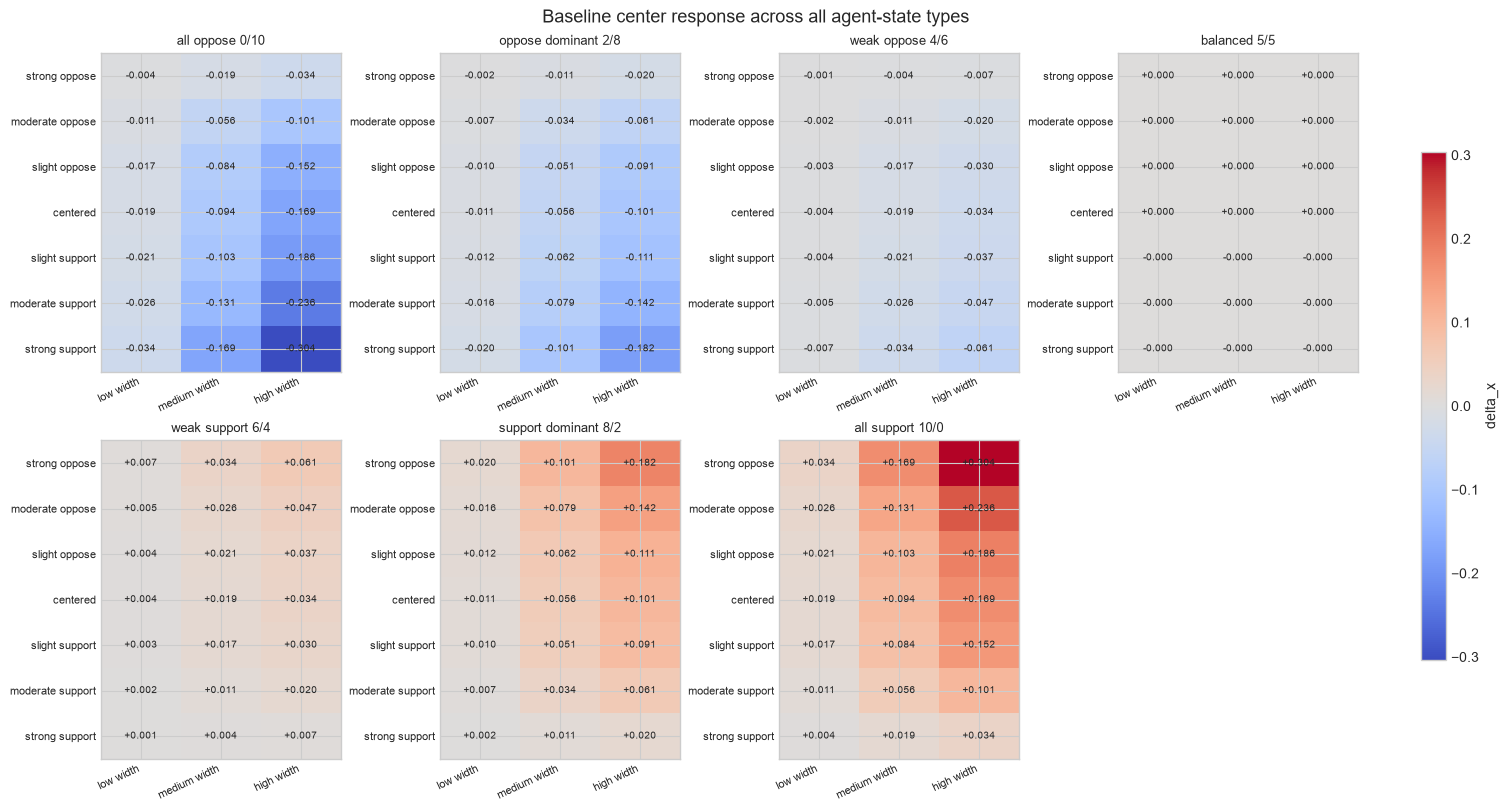

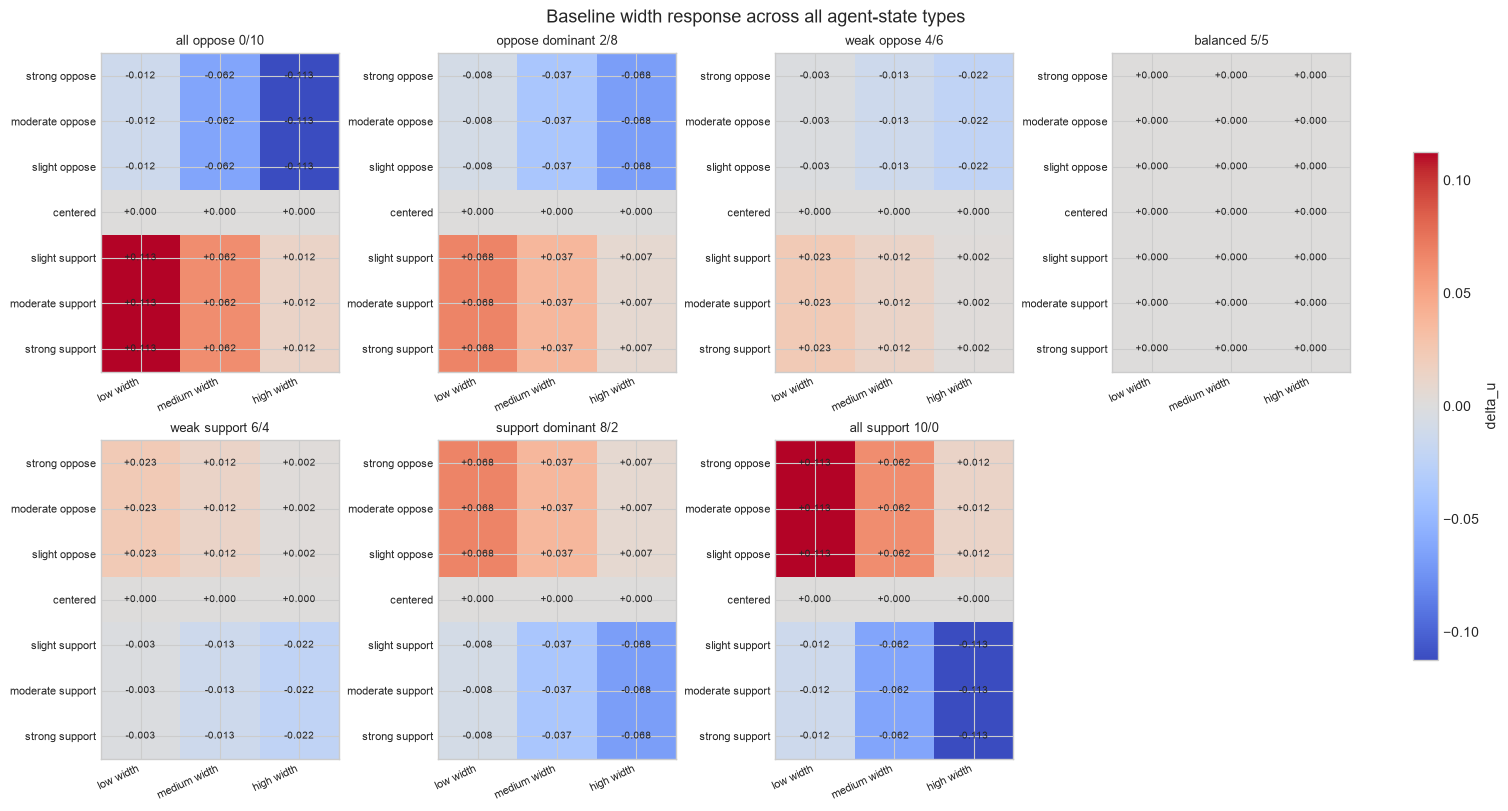

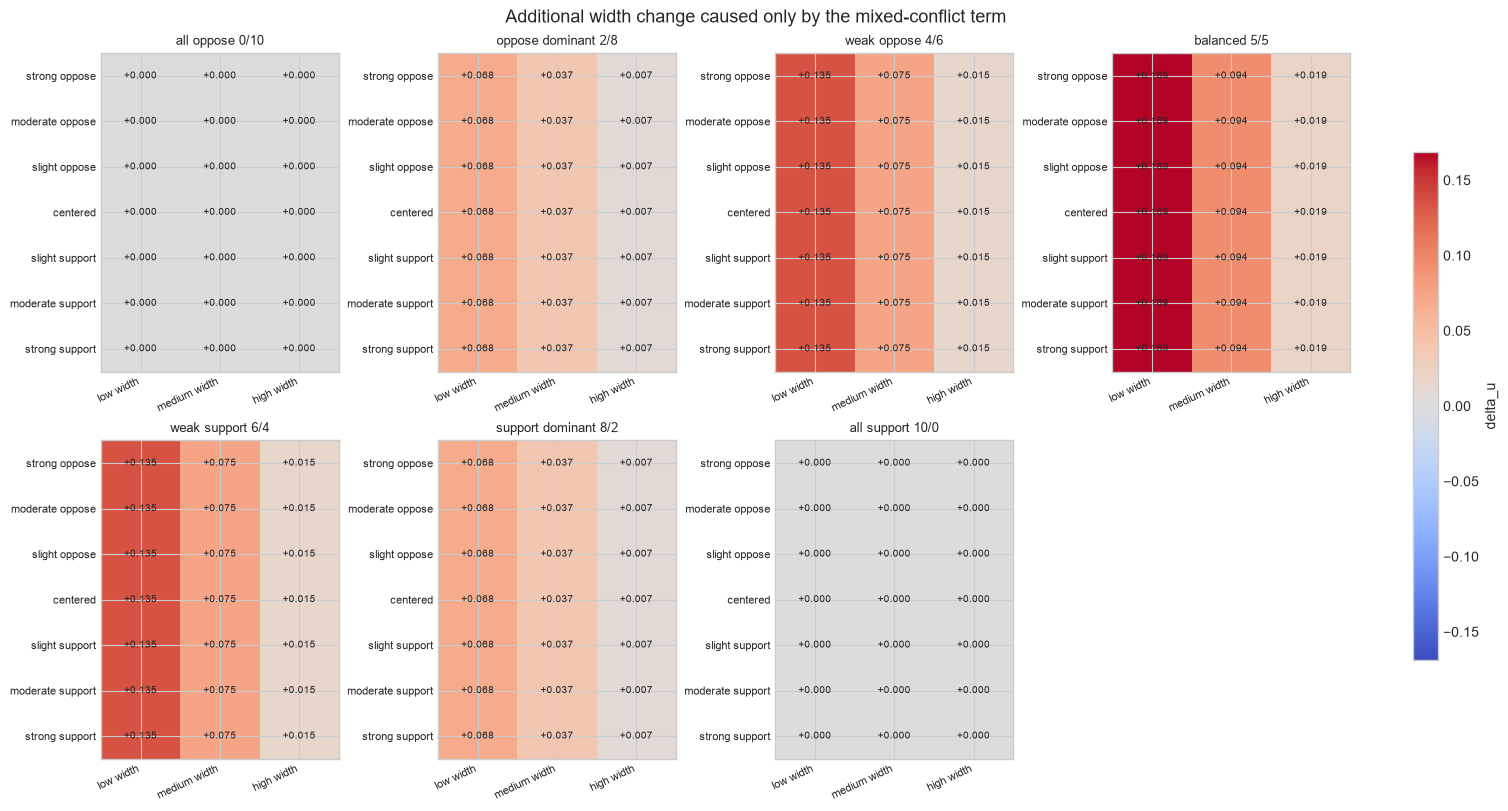

In [8]:
def plot_type_maps(frame, value, mechanism, title, cmap="coolwarm"):
    selected = frame[frame.mechanism == mechanism]
    max_abs = max(float(selected[value].abs().max()), 1e-9)
    fig, axes = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)
    axes = axes.ravel()
    image = None
    for ax, batch in zip(axes, BATCH_TYPES):
        pivot = selected[selected.batch == batch].pivot(
            index="position_type", columns="width_type", values=value
        ).reindex(index=list(POSITION_TYPES), columns=list(WIDTH_TYPES))
        values = pivot.to_numpy(dtype=float)
        image = ax.imshow(values, vmin=-max_abs, vmax=max_abs, cmap=cmap, aspect="auto")
        ax.set_title(batch, fontsize=9)
        ax.set_xticks(range(len(WIDTH_TYPES)), list(WIDTH_TYPES), rotation=25, ha="right", fontsize=8)
        ax.set_yticks(range(len(POSITION_TYPES)), list(POSITION_TYPES), fontsize=8)
        for row in range(values.shape[0]):
            for col in range(values.shape[1]):
                ax.text(col, row, f"{values[row, col]:+.3f}", ha="center", va="center", fontsize=7)
    axes[-1].axis("off")
    fig.colorbar(image, ax=axes.tolist(), shrink=0.72, label=value)
    fig.suptitle(title, fontsize=13)
    plt.show()


plot_type_maps(
    TYPE_RESULTS, "delta_x", "baseline: mixed cancels",
    "Baseline center response across all agent-state types",
)
plot_type_maps(
    TYPE_RESULTS, "delta_u", "baseline: mixed cancels",
    "Baseline width response across all agent-state types",
)

keys = ["position_type", "width_type", "batch"]
base_u = TYPE_RESULTS[TYPE_RESULTS.mechanism == "baseline: mixed cancels"].set_index(keys).delta_u
alt_u = TYPE_RESULTS[TYPE_RESULTS.mechanism == "alternative: mixed widens"].set_index(keys).delta_u
MIXEDNESS_INCREMENT = (alt_u - base_u).rename("delta_u").reset_index()
MIXEDNESS_INCREMENT["mechanism"] = "alternative minus baseline"
plot_type_maps(
    MIXEDNESS_INCREMENT, "delta_u", "alternative minus baseline",
    "Additional width change caused only by the mixed-conflict term",
)

## 12. Optional category-readout diagnostic: $P_-,P_0,P_+$

仅有中心 $x$ 和宽度 $u$ **不能唯一确定**完整的 $b(z)$，所以也不能唯一确定三个类别概率。本节只为检查跨区间读取而采用一个明确的 provisional measurement model：

1. 把 $y=(x+1)/2$ 映射到 $[0,1]$；
2. 令 $Y\sim\operatorname{Beta}(y\kappa,(1-y)\kappa)$，因此 $E[2Y-1]=x$；
3. 用 $\kappa(u)=2+10(1-u)/u$ 把高 $u$ 映射为低 concentration；$u=0$ 单独作为点质量处理；
4. 暂设 neutral threshold $\tau=0.2$，从该分布积分得到 $P_-,P_0,P_+$。

Beta family、$\kappa(u)$ 和 $\tau$ 都是**诊断假设**，不参与 $x,u$ 更新，也尚未进入共享框架。更换这些假设可能改变类别概率和跨界次数。

In [9]:
from scipy.stats import beta as beta_distribution

CATEGORY_NAMES = np.array(["oppose", "neutral", "support"])


def category_probabilities(x, u, tau=0.2):
    """Provisional Beta readout; this is not part of the state-update rule."""
    if not (-1.0 <= x <= 1.0 and 0.0 <= u <= 1.0 and 0.0 < tau < 1.0):
        raise ValueError("Invalid x, u, or tau.")
    if np.isclose(u, 0.0) or np.isclose(abs(x), 1.0):
        if x < -tau:
            return np.array([1.0, 0.0, 0.0]), np.inf
        if x > tau:
            return np.array([0.0, 0.0, 1.0]), np.inf
        return np.array([0.0, 1.0, 0.0]), np.inf

    mean_y = (x + 1.0) / 2.0
    kappa = 2.0 + 10.0 * (1.0 - u) / u
    alpha_shape = mean_y * kappa
    beta_shape = (1.0 - mean_y) * kappa
    lower_y = (1.0 - tau) / 2.0
    upper_y = (1.0 + tau) / 2.0
    cdf_lower = beta_distribution.cdf(lower_y, alpha_shape, beta_shape)
    cdf_upper = beta_distribution.cdf(upper_y, alpha_shape, beta_shape)
    probabilities = np.array([cdf_lower, cdf_upper - cdf_lower, 1.0 - cdf_upper], dtype=float)
    probabilities = np.clip(probabilities, 0.0, 1.0)
    probabilities /= probabilities.sum()
    return probabilities, kappa


def dominant_category(probabilities, atol=1e-9):
    """Return a unique dominant category or 'ambiguous' for a probability tie."""
    winners = CATEGORY_NAMES[np.isclose(probabilities, probabilities.max(), atol=atol, rtol=0.0)]
    return str(winners[0]) if len(winners) == 1 else "ambiguous"


readout_rows = []
for row in TYPE_RESULTS.itertuples(index=False):
    before, kappa_before = category_probabilities(row.x_before, row.u_before)
    after, kappa_after = category_probabilities(row.x_after, row.u_after)
    before_label = dominant_category(before)
    after_label = dominant_category(after)
    readout_rows.append({
        **row._asdict(),
        "P- before": before[0], "P0 before": before[1], "P+ before": before[2],
        "P- after": after[0], "P0 after": after[1], "P+ after": after[2],
        "category before": before_label,
        "category after": after_label,
        "category changed": before_label != after_label,
        "kappa before": kappa_before, "kappa after": kappa_after,
    })
READOUT_RESULTS = pd.DataFrame(readout_rows)

readout_examples = READOUT_RESULTS[
    (READOUT_RESULTS.mechanism == "baseline: mixed cancels")
    & READOUT_RESULTS.position_type.isin(["strong oppose", "centered", "strong support"])
    & READOUT_RESULTS.batch.isin(["all oppose 0/10", "balanced 5/5", "all support 10/0"])
]
display(readout_examples[[
    "position_type", "width_type", "batch", "x_before", "u_before", "x_after", "u_after",
    "P- before", "P0 before", "P+ before", "P- after", "P0 after", "P+ after",
    "category before", "category after", "category changed",
]].round(4))

,position_type,width_type,batch,x_before,u_before,x_after,u_after,P- before,P0 before,P+ before,P- after,P0 after,P+ after,category before,category after,category changed
0,strong oppose,low width,all oppose 0/10,-0.8,0.1,-0.8038,0.0875,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,oppose,oppose,False
3,strong oppose,low width,balanced 5/5,-0.8,0.1,-0.8000,0.1000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,oppose,oppose,False
6,strong oppose,low width,all support 10/0,-0.8,0.1,-0.7662,0.2125,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,oppose,oppose,False
7,strong oppose,medium width,all oppose 0/10,-0.8,0.5,-0.8188,0.4375,0.9939,0.0060,0.0001,0.9979,0.0021,0.0000,oppose,oppose,False
10,strong oppose,medium width,balanced 5/5,-0.8,0.5,-0.8000,0.5000,0.9939,0.0060,0.0001,0.9939,0.0060,0.0001,oppose,oppose,False
13,strong oppose,medium width,all support 10/0,-0.8,0.5,-0.6313,0.5625,0.9939,0.0060,0.0001,0.9429,0.0542,0.0029,oppose,oppose,False
14,strong oppose,high width,all oppose 0/10,-0.8,0.9,-0.8338,0.7875,0.9397,0.0441,0.0162,0.9704,0.0253,0.0043,oppose,oppose,False
17,strong oppose,high width,balanced 5/5,-0.8,0.9,-0.8000,0.9000,0.9397,0.0441,0.0162,0.9397,0.0441,0.0162,oppose,oppose,False
20,strong oppose,high width,all support 10/0,-0.8,0.9,-0.4962,0.9125,0.9397,0.0441,0.0162,0.7628,0.1461,0.0911,oppose,oppose,False
63,centered,low width,all oppose 0/10,0.0,0.1,-0.0188,0.1000,0.0266,0.9467,0.0266,0.0399,0.9428,0.0173,neutral,neutral,False


## 13. Cross-type verification and diagnostic summaries

这些检查覆盖 294 个主实验情形，并额外压力测试 $x=\pm1$ 与 $u=0/1$。通过只说明实现符合候选规则。随后列出类别变化次数、最大中心移动与最大宽度变化，帮助定位值得共同审阅的区域。

In [10]:
def run_cross_type_checks():
    assert len(TYPE_RESULTS) == 294
    assert TYPE_RESULTS.x_after.between(-1.0, 1.0).all()
    assert TYPE_RESULTS.u_after.between(0.0, 1.0).all()

    directional = TYPE_RESULTS[TYPE_RESULTS.b != 0.0]
    assert (directional.delta_x * directional.b >= -1e-12).all()

    balanced_base = TYPE_RESULTS[
        (TYPE_RESULTS.mechanism == "baseline: mixed cancels")
        & (TYPE_RESULTS.batch == "balanced 5/5")
    ]
    assert np.allclose(balanced_base.delta_x, 0.0)
    assert np.allclose(balanced_base.delta_u, 0.0)

    for _, group in TYPE_RESULTS[TYPE_RESULTS.b != 0.0].groupby(
        ["mechanism", "position_type", "batch"], observed=True
    ):
        ordered = group.set_index("width_type").reindex(list(WIDTH_TYPES))
        assert np.all(np.diff(ordered.delta_x.abs().to_numpy()) >= -1e-12)

    probability_columns = ["P- before", "P0 before", "P+ before", "P- after", "P0 after", "P+ after"]
    assert READOUT_RESULTS[probability_columns].ge(0.0).all().all()
    assert READOUT_RESULTS[probability_columns].le(1.0).all().all()
    assert np.allclose(READOUT_RESULTS[["P- before", "P0 before", "P+ before"]].sum(axis=1), 1.0)
    assert np.allclose(READOUT_RESULTS[["P- after", "P0 after", "P+ after"]].sum(axis=1), 1.0)
    symmetric_center, _ = category_probabilities(0.0, 0.9)
    assert np.isclose(symmetric_center[0], symmetric_center[2])
    assert dominant_category(symmetric_center) == "ambiguous"

    stress_params = EffectParams(alpha=1.0, beta=1.0, gamma_mixed=1.0, nu=0.5)
    for x in (-1.0, 1.0):
        for u in (0.0, 1.0):
            for ns, no in BATCH_TYPES.values():
                result = update_one_round(x, u, ns, no, stress_params)
                assert -1.0 <= result.x_after <= 1.0
                assert 0.0 <= result.u_after <= 1.0

    print("Cross-type checks passed: 294 factorial cases, probabilities, monotonic plasticity, and stress bounds.")


run_cross_type_checks()

switch_counts = READOUT_RESULTS.groupby(
    ["mechanism", "batch"], observed=True
)["category changed"].agg(["sum", "count"])
switch_counts["share"] = switch_counts["sum"] / switch_counts["count"]
display(switch_counts)

display(TYPE_RESULTS.nlargest(12, "delta_x")[[
    "mechanism", "position_type", "width_type", "batch", "x_before", "u_before", "delta_x", "delta_u",
]].round(4))
display(TYPE_RESULTS.nlargest(12, "delta_u")[[
    "mechanism", "position_type", "width_type", "batch", "x_before", "u_before", "delta_x", "delta_u",
]].round(4))

Cross-type checks passed: 294 factorial cases, probabilities, monotonic plasticity, and stress bounds.


sum  count     share
mechanism                 batch                                     
alternative: mixed widens all oppose 0/10         3     21  0.142857
                          all support 10/0        3     21  0.142857
                          balanced 5/5            0     21  0.000000
                          oppose dominant 2/8     2     21  0.095238
                          support dominant 8/2    2     21  0.095238
                          weak oppose 4/6         1     21  0.047619
                          weak support 6/4        1     21  0.047619
baseline: mixed cancels   all oppose 0/10         3     21  0.142857
                          all support 10/0        3     21  0.142857
                          balanced 5/5            0     21  0.000000
                          oppose dominant 2/8     2     21  0.095238
                          support dominant 8/2    2     21  0.095238
                          weak oppose 4/6         1     21  0.047619
                          weak support 6/4        1     21  0.047619

,mechanism,position_type,width_type,batch,x_before,u_before,delta_x,delta_u
20,baseline: mixed cancels,strong oppose,high width,all support 10/0,-0.8,0.9,0.3038,0.0125
167,alternative: mixed widens,strong oppose,high width,all support 10/0,-0.8,0.9,0.3038,0.0125
41,baseline: mixed cancels,moderate oppose,high width,all support 10/0,-0.4,0.9,0.2362,0.0125
188,alternative: mixed widens,moderate oppose,high width,all support 10/0,-0.4,0.9,0.2362,0.0125
62,baseline: mixed cancels,slight oppose,high width,all support 10/0,-0.1,0.9,0.1856,0.0125
209,alternative: mixed widens,slight oppose,high width,all support 10/0,-0.1,0.9,0.1856,0.0125
19,baseline: mixed cancels,strong oppose,high width,support dominant 8/2,-0.8,0.9,0.1822,0.0075
166,alternative: mixed widens,strong oppose,high width,support dominant 8/2,-0.8,0.9,0.1822,0.0150
13,baseline: mixed cancels,strong oppose,medium width,all support 10/0,-0.8,0.5,0.1688,0.0625
83,baseline: mixed cancels,centered,high width,all support 10/0,0.0,0.9,0.1688,0.0000


,mechanism,position_type,width_type,batch,x_before,u_before,delta_x,delta_u
150,alternative: mixed widens,strong oppose,low width,balanced 5/5,-0.8,0.1,0.0000,0.1688
171,alternative: mixed widens,moderate oppose,low width,balanced 5/5,-0.4,0.1,0.0000,0.1688
192,alternative: mixed widens,slight oppose,low width,balanced 5/5,-0.1,0.1,0.0000,0.1688
213,alternative: mixed widens,centered,low width,balanced 5/5,0.0,0.1,0.0000,0.1688
234,alternative: mixed widens,slight support,low width,balanced 5/5,0.1,0.1,-0.0000,0.1688
255,alternative: mixed widens,moderate support,low width,balanced 5/5,0.4,0.1,-0.0000,0.1688
276,alternative: mixed widens,strong support,low width,balanced 5/5,0.8,0.1,-0.0000,0.1688
151,alternative: mixed widens,strong oppose,low width,weak support 6/4,-0.8,0.1,0.0068,0.1575
172,alternative: mixed widens,moderate oppose,low width,weak support 6/4,-0.4,0.1,0.0052,0.1575
193,alternative: mixed widens,slight oppose,low width,weak support 6/4,-0.1,0.1,0.0041,0.1575


## 14. Complete agent movement list

下面只展示每个 agent-state 在各信息批次下的移动结果。保留 `mechanism` 是因为两种 mixedness 机制尚未决定；其余诊断量全部从本表移除。完整列表同时导出为 CSV。

In [11]:
from pathlib import Path

POSITION_CN = {
    "strong oppose": "强反对",
    "moderate oppose": "中度反对",
    "slight oppose": "轻微反对",
    "centered": "正中",
    "slight support": "轻微支持",
    "moderate support": "中度支持",
    "strong support": "强支持",
}
WIDTH_CN = {
    "low width": "低宽度",
    "medium width": "中宽度",
    "high width": "高宽度",
}
BATCH_CN = {
    "all oppose 0/10": "0支持/10反对（全反对）",
    "oppose dominant 2/8": "2支持/8反对（反对占优）",
    "weak oppose 4/6": "4支持/6反对（弱反对多数）",
    "balanced 5/5": "5支持/5反对（平衡）",
    "weak support 6/4": "6支持/4反对（弱支持多数）",
    "support dominant 8/2": "8支持/2反对（支持占优）",
    "all support 10/0": "10支持/0反对（全支持）",
}
MECHANISM_CN = {
    "baseline: mixed cancels": "基准：混合信息抵消",
    "alternative: mixed widens": "备选：混合信息扩大宽度",
}

movement = TYPE_RESULTS.copy()
movement["agent"] = (
    movement["position_type"].map(POSITION_CN).astype(str)
    + "｜"
    + movement["width_type"].map(WIDTH_CN).astype(str)
)
movement["mechanism"] = movement["mechanism"].map(MECHANISM_CN)
movement["information_batch"] = movement["batch"].map(BATCH_CN)
MOVEMENT_RESULTS = movement[[
    "mechanism", "agent", "x_before", "u_before", "information_batch", "x_after", "u_after",
]].rename(columns={
    "x_before": "x_t",
    "u_before": "u_t",
    "x_after": "x_t+1",
    "u_after": "u_t+1",
})

output_dir = Path.cwd() / "notebooks"
if not output_dir.is_dir():
    output_dir = Path.cwd()
OUTPUT_CSV = output_dir / "single_agent_movement_results.csv"
MOVEMENT_RESULTS.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"Saved {len(MOVEMENT_RESULTS)} movement rows to: {OUTPUT_CSV.resolve()}")
with pd.option_context("display.max_rows", 400, "display.max_columns", None):
    display(MOVEMENT_RESULTS.round({"x_t": 3, "u_t": 3, "x_t+1": 4, "u_t+1": 4}))

Saved 294 movement rows to: D:\CSS-Research\opinion-dynamics\opinion-model\notebooks\single_agent_movement_results.csv


,mechanism,agent,x_t,u_t,information_batch,x_t+1,u_t+1
0,基准：混合信息抵消,强反对｜低宽度,-0.8,0.1,0支持/10反对（全反对）,-0.8038,0.0875
1,基准：混合信息抵消,强反对｜低宽度,-0.8,0.1,2支持/8反对（反对占优）,-0.8022,0.0925
2,基准：混合信息抵消,强反对｜低宽度,-0.8,0.1,4支持/6反对（弱反对多数）,-0.8008,0.0975
3,基准：混合信息抵消,强反对｜低宽度,-0.8,0.1,5支持/5反对（平衡）,-0.8000,0.1000
4,基准：混合信息抵消,强反对｜低宽度,-0.8,0.1,6支持/4反对（弱支持多数）,-0.7932,0.1225
5,基准：混合信息抵消,强反对｜低宽度,-0.8,0.1,8支持/2反对（支持占优）,-0.7798,0.1675
6,基准：混合信息抵消,强反对｜低宽度,-0.8,0.1,10支持/0反对（全支持）,-0.7662,0.2125
7,基准：混合信息抵消,强反对｜中宽度,-0.8,0.5,0支持/10反对（全反对）,-0.8188,0.4375
8,基准：混合信息抵消,强反对｜中宽度,-0.8,0.5,2支持/8反对（反对占优）,-0.8112,0.4625
9,基准：混合信息抵消,强反对｜中宽度,-0.8,0.5,4支持/6反对（弱反对多数）,-0.8038,0.4875


## 14. Conditional interpretation, disposition, and change impact

运行后分别检查：

- **V0 software verification:** 手算、边界、镜像对称、同步时序，以及 294 个主实验情形的跨类型断言。
- **V1 isolated behavior:** 响应热图、类别概率诊断和 category-switch 区域是否符合研究直觉。
- **Competing mechanisms:** `mixed cancels` 与 `mixed widens` 都保留；哪一个更合理不能由模拟自身决定。
- **Category readout limitation:** $P_-,P_0,P_+$ 依赖 provisional Beta family、$\kappa(u)$ 和 $\tau$，不是由 $(x,u)$ 唯一推出，也不参与动态更新。
- **Does not establish:** 参数真实性、因果有效性、长期稳定性、跨 agent 互动、网络扩散或群体极化。
- **Open evidence:** 控制初始位置与不确定性，比较同向一致、反向一致、平衡混合和弱多数批次后的连续位置、不确定性与类别判断。
- **Current disposition:** `unresolved`；函数族只作为 provisional benchmark。

### Change impact

本 notebook 现在覆盖状态原型而非单个示例，但仍是隔离单轮探针。旧的 $S,C$ 状态解释和同轮重新确信结果继续标记为 **stale**。新增 category readout 只是测量层候选，不能被其他代码当作已确认的共享接口。
### Observed in the current provisional parameter slice

- 全部 294 个 state × batch × mechanism 情形、概率归一化、宽度—可塑性单调关系和 $x=\pm1,u=0/1$ 压力边界均通过检查。
- 对强反对者收到全支持信息，$u=0.1,0.5,0.9$ 时的 $\Delta x$ 分别约为 $0.034,0.169,0.304$：旧宽度越高，同轮中心位移越大。
- 同一反向一致批次使低宽度 agent 的 $u$ 上升更多，而高宽度 agent 因接近上界只小幅上升；这产生“先动摇”和“直接移动”程度的差异。
- baseline 的平衡批次对所有 21 个状态原型均令 $\Delta x=\Delta u=0$。$\gamma=0.3$ 时，同一平衡批次可使 $u=0.1$ 的 agent 增加约 $0.169$，且该效应与 $x$ 无关。
- 在当前 Beta readout 下，完全单向批次使 3/21 的状态原型改变 dominant category，强多数为 2/21，弱多数为 1/21，平衡批次为 0/21；两种 mixedness 机制在这些离散标签计数上暂未被区分。
- 对 $x=0,u=0.9$，诊断分布给出 $P_-\approx P_+\approx0.371>P_0\approx0.258$，因此正确标签是 `ambiguous`，而不是由浮点 `argmax` 任意指定支持或反对。这个结果高度依赖 Beta family 与 $\kappa(u)$，是测量层警示，不是行为结论。
### Movement-list artifact

`MOVEMENT_RESULTS` 与 `single_agent_movement_results.csv` 是面向结果查看的简化投影，只包含机制、agent 初始状态、信息批次与更新后的 $x_{t+1},u_{t+1}$；完整研究诊断仍保留在前面的 cells 中。